# V5.3 — Semantic backbone + Confirmation gate

V5.3 проверяет более осторожную версию confirmation layer: `Semantic active v3` остаётся основным backbone, а anchor–challenger используется как gate. Если anchor подтверждён и состояние стабильно — сессию можно остановить. Если challenger выигрывает — делаем маленькую zone-aware коррекцию и возвращаемся к semantic backbone.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from personalization.plotting import use_article_style
use_article_style()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from personalization.batch_eval import win_rates_vs_baseline
from personalization.safe_anchor_challenger_v51 import V51_STRATEGY_NAME
from personalization.safe_anchor_challenger_v52 import V52_STRATEGY_NAME
from personalization.safe_anchor_challenger_v53 import (
    V53_DISPLAY_NAMES,
    V53_STRATEGY_NAME,
    run_v53_comparison_on_dataset,
    save_v53_outputs,
    source_usage_table_v53,
    summarize_v53_sessions,
)

DATASET_PATH = ROOT / 'outputs' / 'datasets' / 'synthetic_users_v21.csv'
FIG_DIR = ROOT / 'outputs' / 'figures'
TABLE_DIR = ROOT / 'outputs' / 'tables'
METRICS_DIR = ROOT / 'outputs' / 'metrics'

TARGET_MODE_DISPLAY_NAMES = {
    'random8d': 'Random 8D',
    'semantic4d': 'Semantic 4D',
    'semantic6d': 'Semantic 6D',
    'archetype8d': 'Archetype 8D',
}
TARGET_MODE_ORDER = ['random8d', 'semantic4d', 'semantic6d', 'archetype8d']
STRATEGY_ORDER = [
    'semantic_active_v21',
    'candidate_pool_active',
    V51_STRATEGY_NAME,
    V52_STRATEGY_NAME,
    V53_STRATEGY_NAME,
]


## Загрузка dataset

In [2]:
dataset = pd.read_csv(DATASET_PATH)
SAMPLE_PER_MODE = 50  # поставь None или 0 для полного dataset

if SAMPLE_PER_MODE is None or SAMPLE_PER_MODE <= 0:
    dataset_eval = dataset.copy()
else:
    sampled_parts = []
    for _, group in dataset.groupby('target_mode'):
        sampled_parts.append(group.sample(n=min(SAMPLE_PER_MODE, len(group)), random_state=42))
    dataset_eval = pd.concat(sampled_parts, axis=0).reset_index(drop=True)

dataset_eval['target_mode'].value_counts()


target_mode
archetype8d    50
random8d       50
semantic4d     50
semantic6d     50
Name: count, dtype: int64

## Запуск эксперимента

In [3]:
sessions, steps, curves = run_v53_comparison_on_dataset(
    dataset_eval,
    baseline_strategies=('semantic_active_v21', 'candidate_pool_active'),
    include_v5=False,
    include_v51=True,
    include_v52=True,
    n_steps=25,
    step_scale=0.6,
    lr=0.25,
    clip_value=2.0,
)
summary = summarize_v53_sessions(sessions)
win_rates = win_rates_vs_baseline(sessions, baseline='semantic_active_v21')
source_usage = source_usage_table_v53(steps)
summary


,target_mode,strategy,users,mean_used_steps,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,...,mean_confirmation_blocks,mean_anchor_selected_rate,mean_challenger_selected_rate,mean_challenger_corrections,stop_rate,mean_pair_distance,mean_audibility_score,mean_acceptability_score,mean_midrange_penalty,mean_applied_lr
2,archetype8d,semantic_active_v21,50,25.00,1.095608,0.360155,0.098427,0.263306,0.561904,59.974178,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,archetype8d,semantic_backbone_confirmation_gate_v53,50,21.14,1.095608,0.411584,0.169547,0.324707,0.572912,52.292096,...,1.62,0.616667,0.383333,1.06,0.56,0.777551,0.668243,0.988787,0.011923,0.186684
1,archetype8d,safe_anchor_challenger_v51,50,25.00,1.095608,0.422383,0.195692,0.372829,0.595770,54.650715,...,NaN,NaN,NaN,NaN,NaN,0.648915,0.663967,0.985910,0.018757,0.146844
4,archetype8d,semantic_backbone_confirmation_v52,50,16.06,1.095608,0.459850,0.208367,0.373403,0.589182,50.942234,...,NaN,0.640000,NaN,NaN,NaN,0.593211,0.679401,0.989052,0.011698,0.141752
0,archetype8d,candidate_pool_active,50,25.00,1.095608,0.492750,0.116158,0.340776,0.625183,39.785242,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,random8d,candidate_pool_active,50,25.00,2.121827,0.970351,0.411712,0.944272,1.495394,55.091709,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,random8d,semantic_active_v21,50,25.00,2.121827,1.437350,0.491156,1.409565,1.665743,31.383912,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,random8d,semantic_backbone_confirmation_gate_v53,50,20.80,2.121827,1.519515,0.494196,1.490149,1.682884,27.942848,...,1.60,0.641667,0.358333,0.98,0.62,0.764647,0.684813,0.986538,0.014107,0.183372
6,random8d,safe_anchor_challenger_v51,50,25.00,2.121827,1.557640,0.544007,1.540380,1.702146,26.824981,...,NaN,NaN,NaN,NaN,NaN,0.655100,0.695850,0.984846,0.020260,0.147632
9,random8d,semantic_backbone_confirmation_v52,50,16.00,2.121827,1.562699,0.509530,1.543206,1.693596,26.207044,...,NaN,0.600000,NaN,NaN,NaN,0.591329,0.720695,0.986428,0.014207,0.141280


In [4]:
METRICS_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

save_v53_outputs(sessions, steps, summary, win_rates, source_usage, METRICS_DIR)
summary.to_csv(TABLE_DIR / 'article_v53_confirmation_gate_summary.csv', index=False)
win_rates.to_csv(TABLE_DIR / 'article_v53_confirmation_gate_win_rates.csv', index=False)
source_usage.to_csv(TABLE_DIR / 'article_v53_confirmation_gate_source_usage.csv', index=False)


## Графики

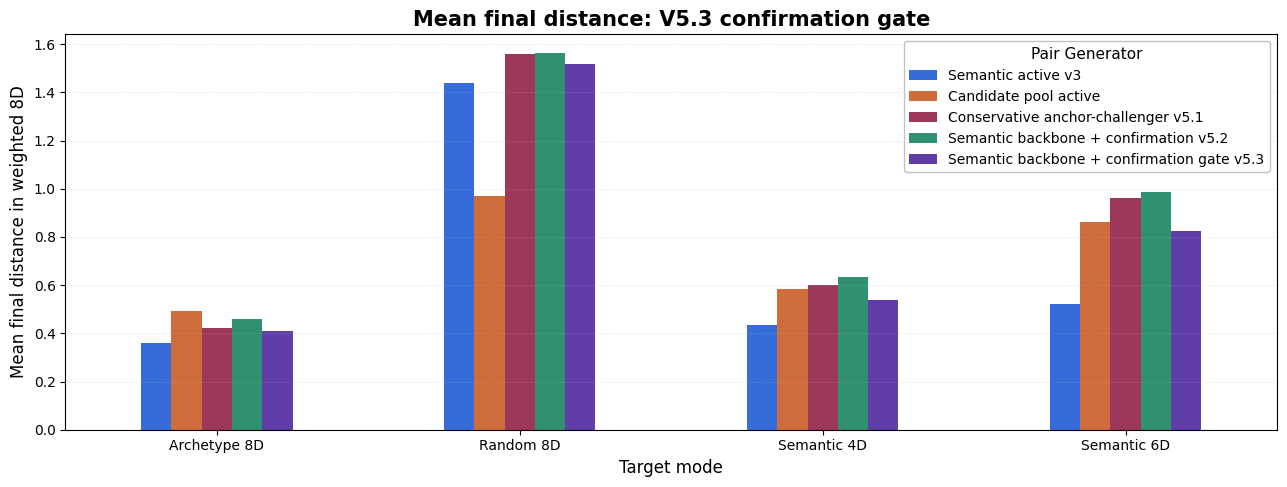

In [5]:
def add_display_columns(df):
    out = df.copy()
    out['target_mode_display'] = out['target_mode'].map(TARGET_MODE_DISPLAY_NAMES).fillna(out['target_mode'])
    out['strategy_display'] = out['strategy'].map(V53_DISPLAY_NAMES).fillna(out['strategy'])
    return out

df = add_display_columns(summary)
df = df[df['strategy'].isin(STRATEGY_ORDER)].copy()
df['target_mode'] = pd.Categorical(df['target_mode'], TARGET_MODE_ORDER, ordered=True)
df['strategy'] = pd.Categorical(df['strategy'], STRATEGY_ORDER, ordered=True)
df = df.sort_values(['target_mode', 'strategy'])
pivot = df.pivot(index='target_mode_display', columns='strategy_display', values='mean_final_distance')
cols = [V53_DISPLAY_NAMES[s] for s in STRATEGY_ORDER if V53_DISPLAY_NAMES.get(s) in pivot.columns]
pivot = pivot[cols]

fig, ax = plt.subplots(figsize=(13, 5), facecolor='white')
pivot.plot(kind='bar', ax=ax)
ax.set_title('Mean final distance: V5.3 confirmation gate', fontsize=15, fontweight='bold')
ax.set_xlabel('Target mode')
ax.set_ylabel('Mean final distance in weighted 8D')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.legend(title='Pair Generator', frameon=True, facecolor='white', edgecolor='0.75')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'article_v53_mean_final_distance_by_target.png', dpi=180, bbox_inches='tight')
plt.show()


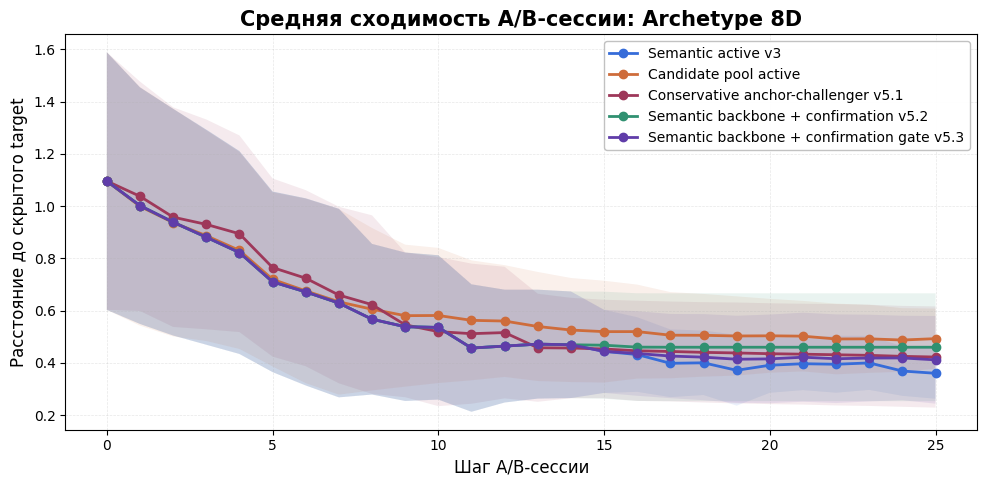

In [6]:
mode = 'archetype8d'
fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')
for strategy in STRATEGY_ORDER:
    arr = curves.get(mode, {}).get(strategy)
    if arr is None or len(arr) == 0:
        continue
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)
    x = np.arange(len(mean))
    ax.plot(x, mean, marker='o', linewidth=2, label=V53_DISPLAY_NAMES.get(strategy, strategy))
    ax.fill_between(x, mean - std, mean + std, alpha=0.10)
ax.set_title('Средняя сходимость A/B-сессии: Archetype 8D', fontsize=15, fontweight='bold')
ax.set_xlabel('Шаг A/B-сессии')
ax.set_ylabel('Расстояние до скрытого target')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, facecolor='white', edgecolor='0.75')
plt.tight_layout()
plt.savefig(FIG_DIR / 'article_v53_convergence_archetype8d.png', dpi=180, bbox_inches='tight')
plt.show()


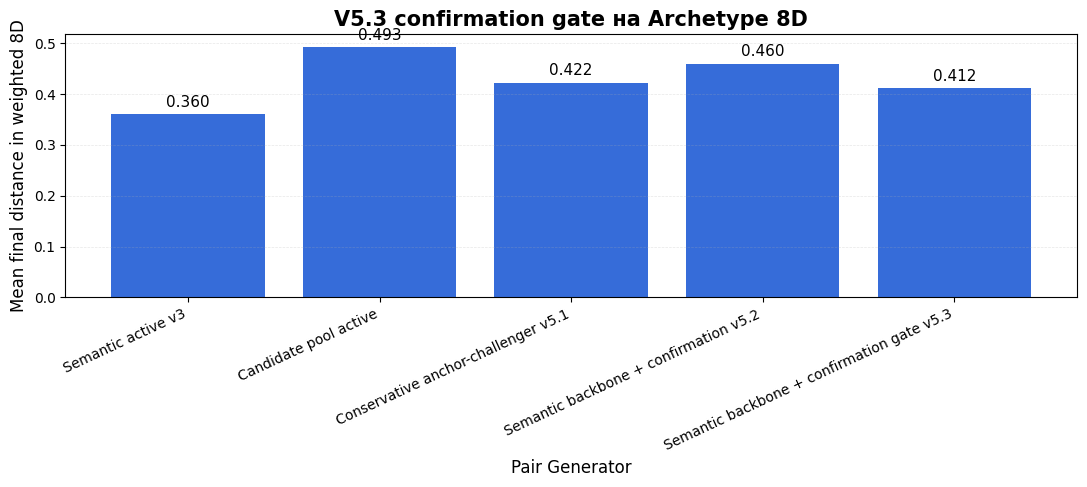

In [7]:
df_a = add_display_columns(summary)
df_a = df_a[(df_a['target_mode'] == 'archetype8d') & (df_a['strategy'].isin(STRATEGY_ORDER))].copy()
df_a['strategy'] = pd.Categorical(df_a['strategy'], STRATEGY_ORDER, ordered=True)
df_a = df_a.sort_values('strategy')

fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
bars = ax.bar(df_a['strategy_display'], df_a['mean_final_distance'])
ax.set_title('V5.3 confirmation gate на Archetype 8D', fontsize=15, fontweight='bold')
ax.set_xlabel('Pair Generator')
ax.set_ylabel('Mean final distance in weighted 8D')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.bar_label(bars, fmt='%.3f', padding=3)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'article_v53_archetype8d_final_distance.png', dpi=180, bbox_inches='tight')
plt.show()


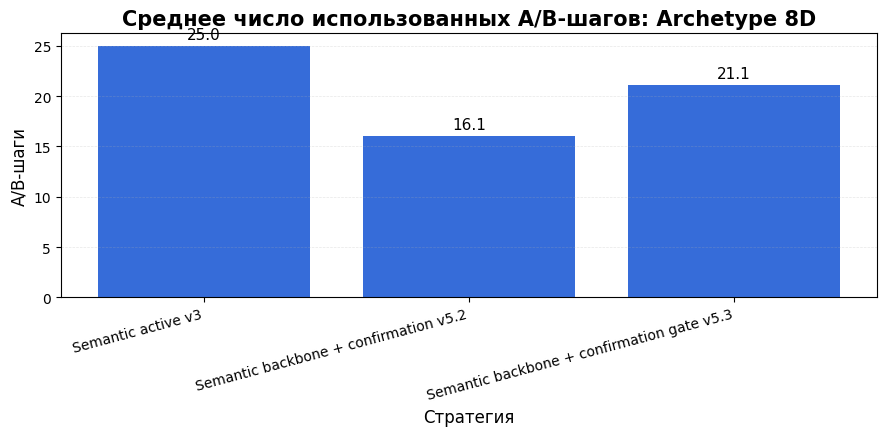

In [8]:
df_steps = add_display_columns(summary)
order = ['semantic_active_v21', V52_STRATEGY_NAME, V53_STRATEGY_NAME]
df_steps = df_steps[(df_steps['target_mode'] == 'archetype8d') & (df_steps['strategy'].isin(order))].copy()
df_steps['strategy'] = pd.Categorical(df_steps['strategy'], order, ordered=True)
df_steps = df_steps.sort_values('strategy')

fig, ax = plt.subplots(figsize=(9, 4.5), facecolor='white')
bars = ax.bar(df_steps['strategy_display'], df_steps['mean_used_steps'])
ax.set_title('Среднее число использованных A/B-шагов: Archetype 8D', fontsize=15, fontweight='bold')
ax.set_xlabel('Стратегия')
ax.set_ylabel('A/B-шаги')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.bar_label(bars, fmt='%.1f', padding=3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'article_v53_used_steps_archetype8d.png', dpi=180, bbox_inches='tight')
plt.show()


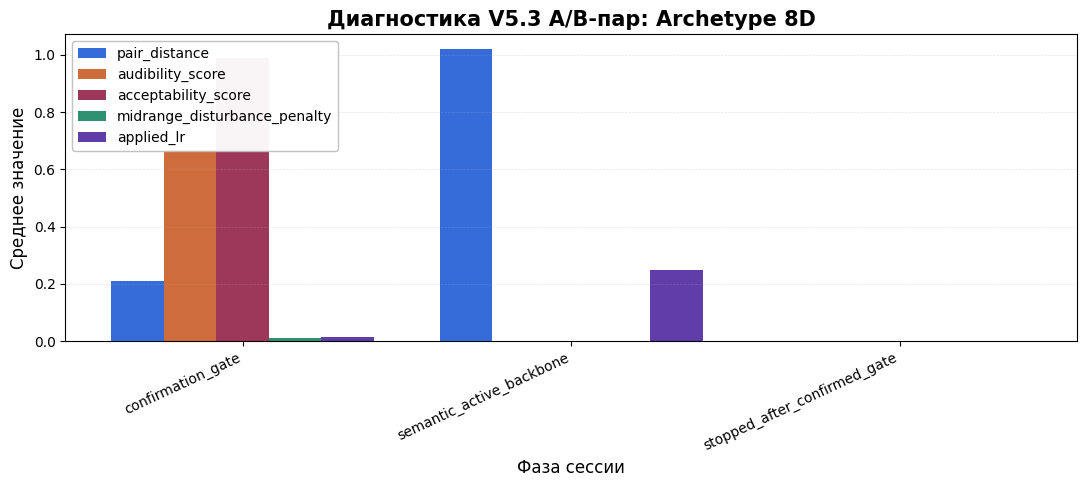

In [9]:
df_q = steps[(steps['target_mode'] == 'archetype8d') & (steps['strategy'] == V53_STRATEGY_NAME)].copy()
metrics = ['pair_distance', 'audibility_score', 'acceptability_score', 'midrange_disturbance_penalty', 'applied_lr']
grouped = df_q.groupby('phase')[metrics].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
x = np.arange(len(grouped))
width = 0.16
for i, metric in enumerate(metrics):
    ax.bar(x + (i - 2) * width, grouped[metric], width=width, label=metric)
ax.set_title('Диагностика V5.3 A/B-пар: Archetype 8D', fontsize=15, fontweight='bold')
ax.set_xlabel('Фаза сессии')
ax.set_ylabel('Среднее значение')
ax.set_xticks(x)
ax.set_xticklabels(grouped['phase'], rotation=25, ha='right')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.legend(frameon=True, facecolor='white', edgecolor='0.75')
plt.tight_layout()
plt.savefig(FIG_DIR / 'article_v53_pair_quality_archetype8d.png', dpi=180, bbox_inches='tight')
plt.show()


## Вывод

`V5.3 confirmation gate` проверяет идею, что anchor–challenger должен быть не hard-stop механизмом, а gate: подтверждать найденный профиль или возвращать систему к `Semantic active v3`. Если результат окажется близким к `Semantic active v3`, но использует меньше шагов, его можно рассматривать как UX-режим короткой сессии. Если он уступает по quality, `Semantic active v3` остаётся основным Pair Generator, а confirmation gate — дополнительным продуктовым слоем.